In [17]:
import numpy as np
from matplotlib import pyplot as plt

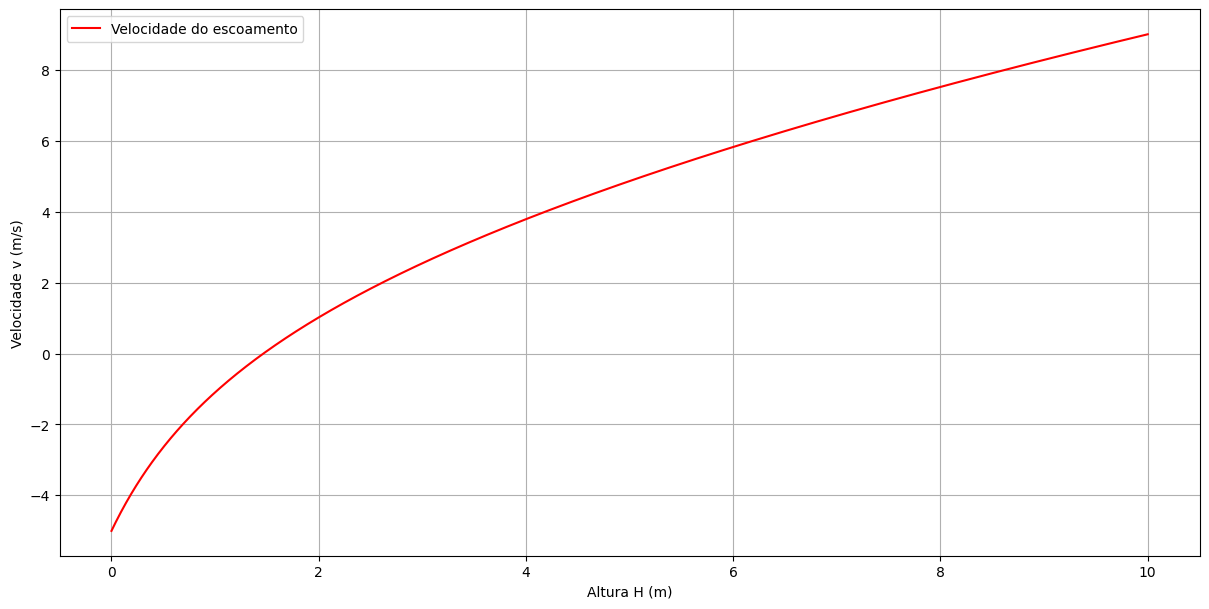

In [18]:
G = 9.81
V = 5
T = 2.5
L = 4
F = lambda H: np.sqrt(2*G*H)*np.tanh(((np.sqrt(2*G*H))/(2*L)) * T) - V
pontosx = np.linspace(0,10,1000)

plt.figure(figsize=(12,6))
plt.plot(pontosx, F(pontosx), "-r", label="Velocidade do escoamento")
plt.tight_layout()
plt.grid()
plt.xlabel('Altura H (m)')
plt.ylabel('Velocidade v (m/s)')
plt.legend()
plt.show()

# Pelo método gráfico, estimo que a raiz da função esta entre 0 e 2, sendo aproximadamente 1.5

---
## Método do intervalo Fechado: 
Pega dois X antes e depois da raiz (x_l e x_u)
 - f(x_l) * f(x_u) < 0  -- Devem ter sinais opostos

In [5]:
# Peguei o ponto 1 e 2, jogando na função um é negativo e outro é positivo, Agora podemos aplicar Bissecção ou Falsa Posição para encontrar o valor exato.
x_l = 1
x_u = 2
fx_l = F(x_l)
fx_u = F(x_u)
print(fx_l, fx_u)

-1.0937205474837897 1.0192731835899531


---

# Método da Bissecção

1. Escolha $x_L$ e $x_U$ em um intervalo de interesse, verifique se $f(x_L) \cdot f(x_U) < 0$.
2. Estime as raízes calculando: $x_R = \frac{x_L + x_U}{2}$ e $f(x_R)$.
3. Se $f(x_L) \cdot f(x_R) < 0$ então a raiz se encontra no intervalo inferior, então $x_U = x_R$ e volte ao passo 2.
4. Se $f(x_L) \cdot f(x_R) > 0$ então a raiz se encontra no intervalo superior, então $x_L = x_R$, volte ao passo 2.
5. Se $f(x_L) \cdot f(x_R) = 0$ então a raiz é $x_R$ e termina.



In [27]:
def bissec(xl: int, xu: int):
    xr = (xl + xu)/2 # Calcula o primeiro xr
    
    # Plot e print apenas para copiar na prova escrita
    print(f"xl = {xl}\nF(xl) = {F(xl)}\n\nXu = {xu}\nF(xl) = {F(xl)}\n\nxr = {xr}\nF(xl) = {F(xr)}\n\n")
    pontosx = np.linspace(0,10,1000) 
    plt.figure(figsize=(12,6))
    plt.plot(pontosx, F(pontosx), "-r", label="Velocidade do escoamento")
    plt.plot(xu, F(xu), "rd", label="Xu")
    plt.plot(xl, F(xl), "kd", label="Xl")
    plt.plot(xr, F(xr), "gd", label="Xr")
    plt.tight_layout()
    plt.grid()
    plt.legend()
    plt.show()
    print("================================")
    # ---------------------------------------------------
    
    erro = 10 # Só p iniciar o loop
    while round(erro,4) >= 1: # Enquanto o erro for maior doq 1%
        xr_antigo = xr # O xr será atualizado e para calcular o erro eu preciso do xr_antigo
        if F(xr) * F(xl) < 0: #Validação da regra 
            xu = xr
        else:
            xl = xr
        xr = (xl + xu)/2 #atualiza o xr
        erro = round(np.abs(((xr - xr_antigo)/xr) * 100), 4) #Calcula o erro
        
    # Plot e print apenas para copiar na prova escrita
        print(f"xl = {xl}\nF(xl) = {F(xl)}\n\nXu = {xu}\nF(xl) = {F(xl)}\n\nxr = {xr}\nF(xl) = {F(xr)}\n\n")
        print(f"Erro = ({xr} - {xr_antigo}) / {xr} = {erro}")
        
        plt.figure(figsize=(12,6))
        plt.plot(pontosx, F(pontosx), "-r", label="Velocidade do escoamento")
        plt.plot(xu, F(xu), "rd", label="Xu")
        plt.plot(xl, F(xl), "kd", label="Xl")
        plt.plot(xr, F(xr), "gd", label="Xr")
        plt.tight_layout()
        plt.grid()
        plt.legend()
        plt.show()
        plt.pause(2)
        print("================================")
    # ---------------------------------------------------
    return xr, erro


xl = 1
F(xl) = -1.0937205474837897

Xu = 2
F(xl) = -1.0937205474837897

xr = 1.5
F(xl) = 0.0713351042635546




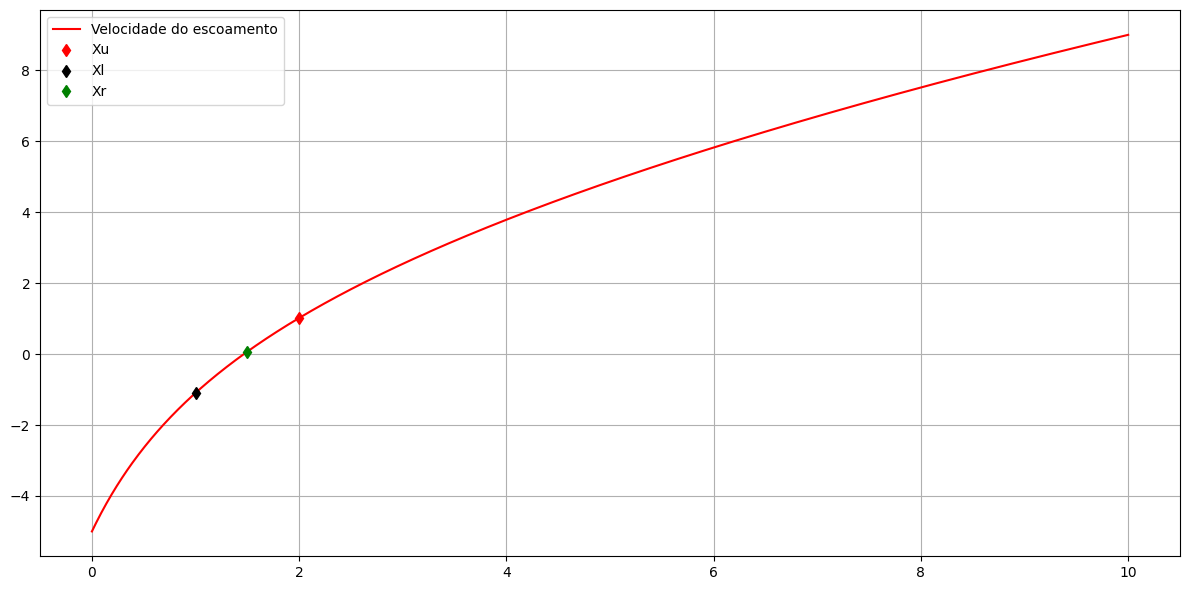

xl = 1
F(xl) = -1.0937205474837897

Xu = 1.5
F(xl) = -1.0937205474837897

xr = 1.25
F(xl) = -0.47666313270744975


Erro = (1.25 - 1.5) / 1.25 = 20.0


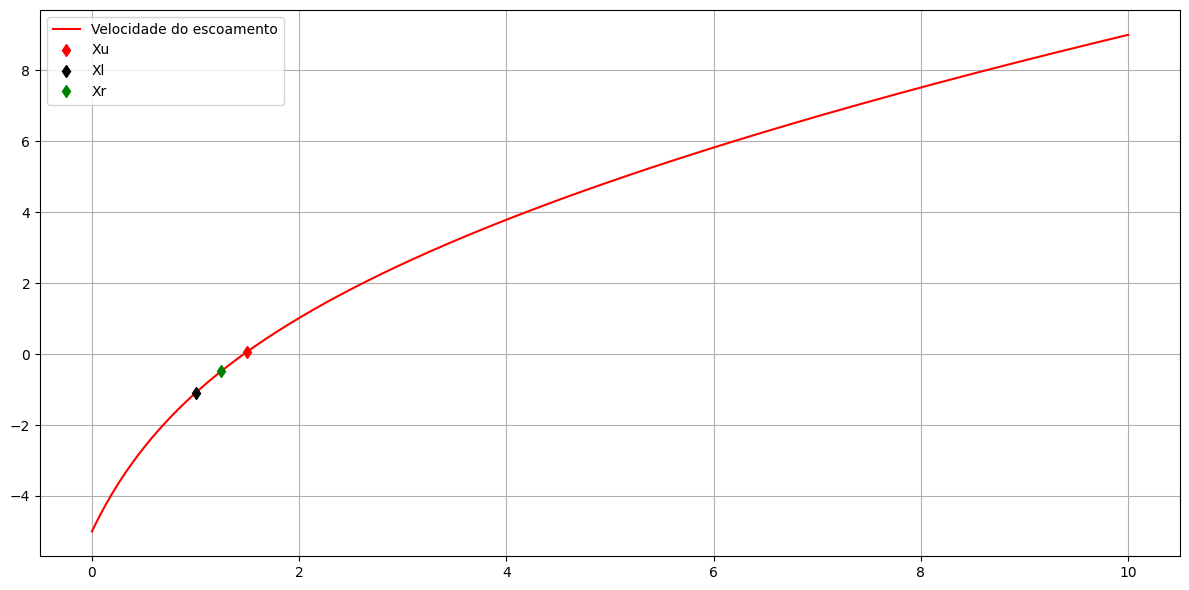

xl = 1.25
F(xl) = -0.47666313270744975

Xu = 1.5
F(xl) = -0.47666313270744975

xr = 1.375
F(xl) = -0.19516910613045457


Erro = (1.375 - 1.25) / 1.375 = 9.0909


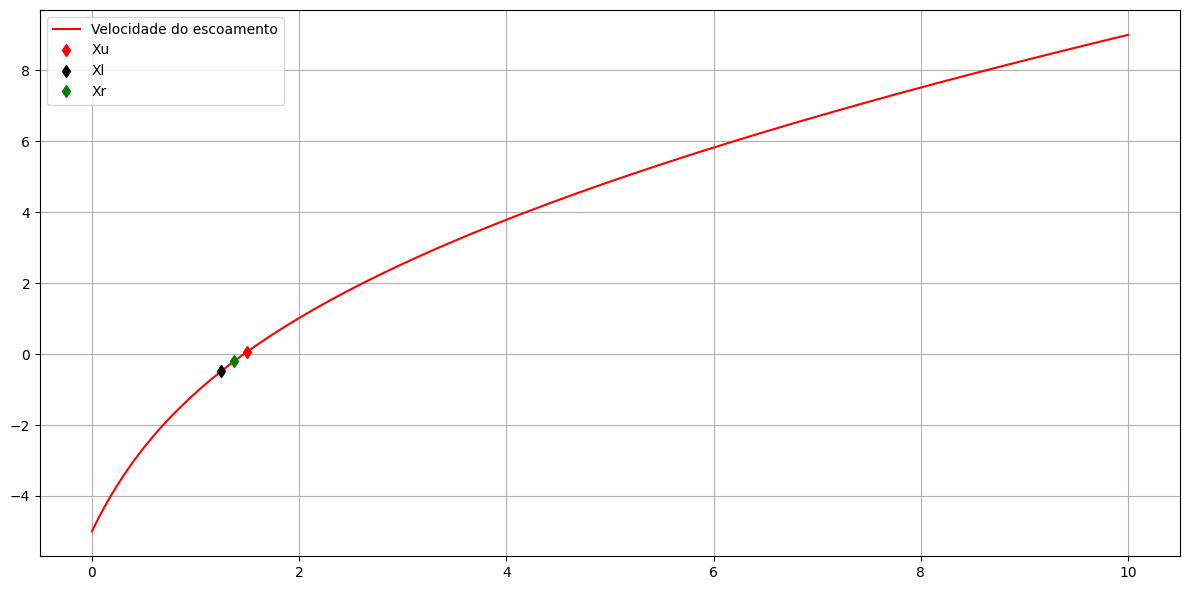

xl = 1.375
F(xl) = -0.19516910613045457

Xu = 1.5
F(xl) = -0.19516910613045457

xr = 1.4375
F(xl) = -0.06016290703391114


Erro = (1.4375 - 1.375) / 1.4375 = 4.3478


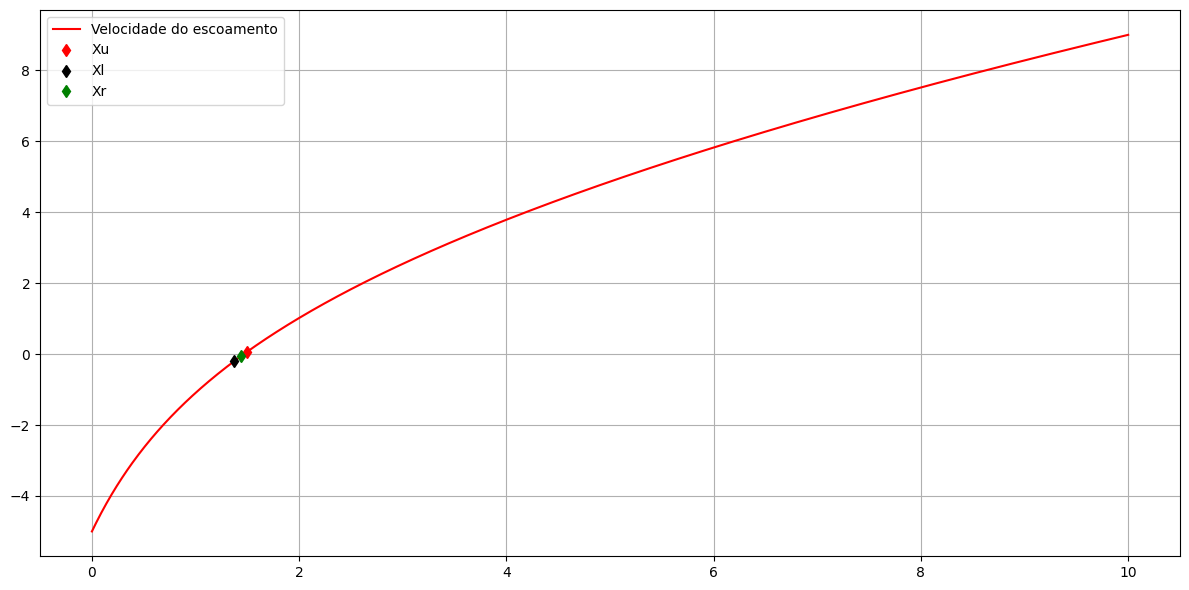

xl = 1.4375
F(xl) = -0.06016290703391114

Xu = 1.5
F(xl) = -0.06016290703391114

xr = 1.46875
F(xl) = 0.006010838389600259


Erro = (1.46875 - 1.4375) / 1.46875 = 2.1277


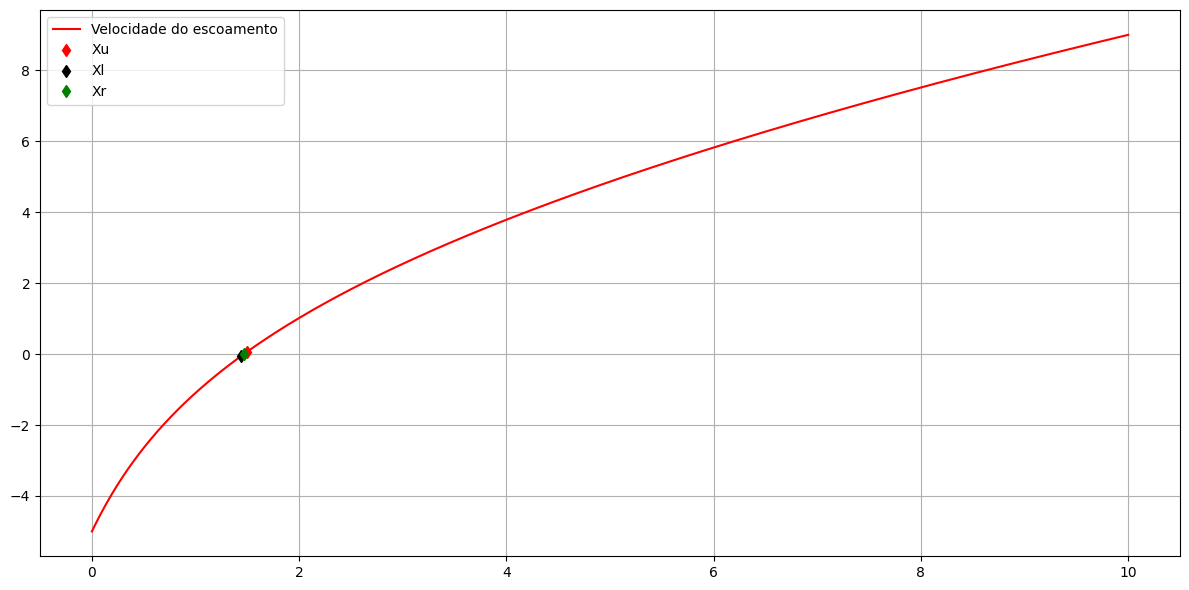

xl = 1.4375
F(xl) = -0.06016290703391114

Xu = 1.46875
F(xl) = -0.06016290703391114

xr = 1.453125
F(xl) = -0.02696817480621938


Erro = (1.453125 - 1.46875) / 1.453125 = 1.0753


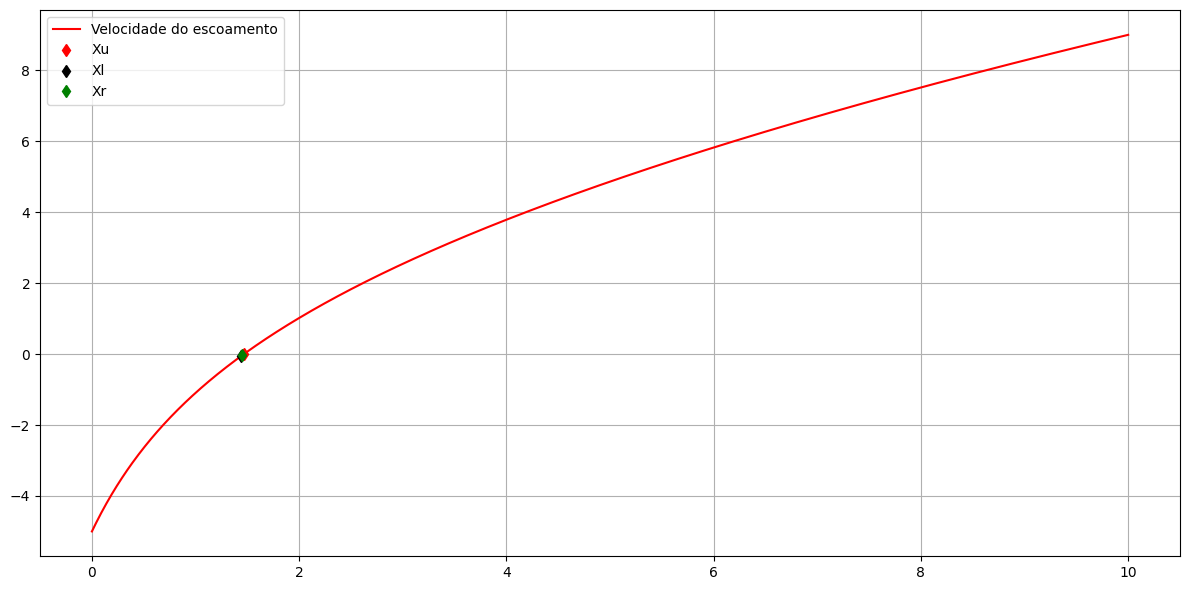

xl = 1.453125
F(xl) = -0.02696817480621938

Xu = 1.46875
F(xl) = -0.02696817480621938

xr = 1.4609375
F(xl) = -0.010451915580971693


Erro = (1.4609375 - 1.453125) / 1.4609375 = 0.5348


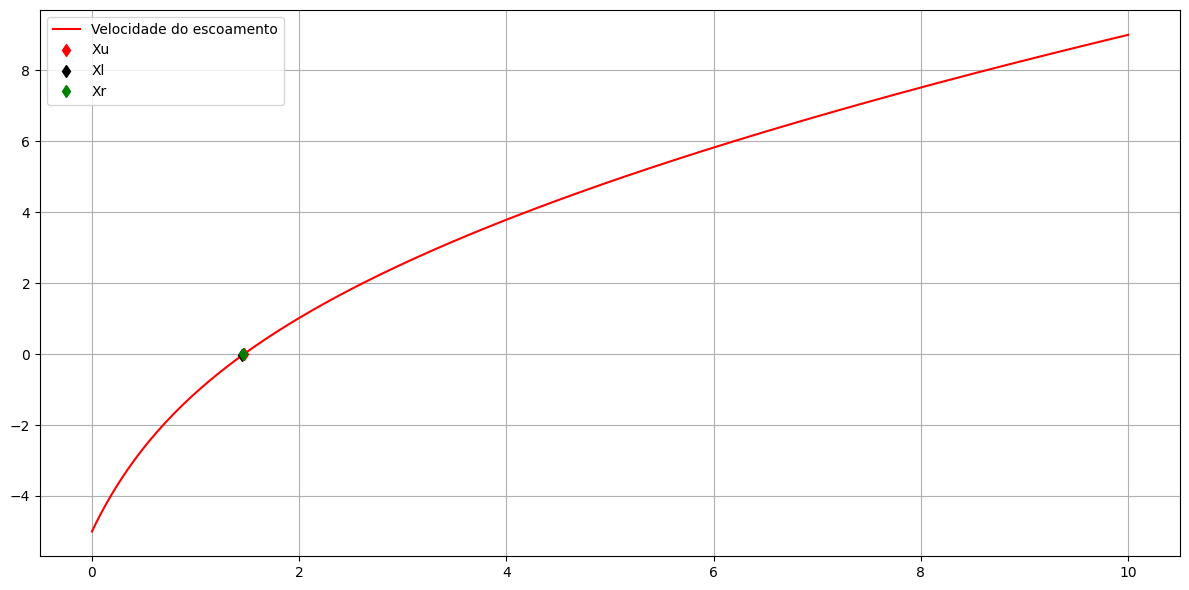

(1.4609375, np.float64(0.5348))

In [28]:
bissec(1,2)

---
# Método da Falsa Posição

In [34]:
def fals_posi(xl, xu):
    xr = xu - ((F(xu) * (xl - xu)) / (F(xl) - F(xu)))
    erro = 10
    
    print(f"xl = {xl}\nF(xl) = {F(xl)}\n\nXu = {xu}\nF(xu) = {F(xu)}\n\nXr = {xr}\nF(xr) = {F(xr)}\n\n")
    pontosx = np.linspace(0,10,1000) 
    plt.figure(figsize=(10,6))
    plt.plot(pontosx, F(pontosx), "-b", label="Função")
    plt.plot(xl, F(xl), "kd", label="Xl")
    plt.plot(xu, F(xu), "rd", label="Xu")
    plt.plot(xr, F(xr), "gd", label="Xr")
    plt.legend()
    plt.grid()
    plt.show()
    
    while erro >= 1:
        xr_antigo = xr

        if F(xr) * F(xl) < 0:
            xu = xr
        else:
            xl = xr
        
        xr = xu - ((F(xu) * (xl - xu)) / (F(xl) - F(xu)))
        erro = round((np.abs((xr - xr_antigo)/ xr)) * 100 ,4)
        
        print(f"xl = {xl}\nF(xl) = {F(xl)}\n\nXu = {xu}\nF(xu) = {F(xu)}\n\nXr = {xr}\nF(xr) = {F(xr)}\n\n")
        print(f"Erro = {xr} - {xr_antigo} / {xr} = {erro}")
        pontosx = np.linspace(0,10,1000) 
        plt.figure(figsize=(10,6))
        plt.plot(pontosx, F(pontosx), "-b", label="Função")
        plt.plot(xl, F(xl), "kd", label="Xl")
        plt.plot(xu, F(xu), "rd", label="Xu")
        plt.plot(xr, F(xr), "gd", label="Xr")
        plt.legend()
        plt.grid()
        plt.show()
        plt.pause(2)
    return {
        "Erro": erro,
        "Raiz": xr
    }

xl = 1
F(xl) = -1.0937205474837897

Xu = 2
F(xu) = 1.0192731835899531

Xr = 1.5176165605224028
F(xr) = 0.10779579481488533




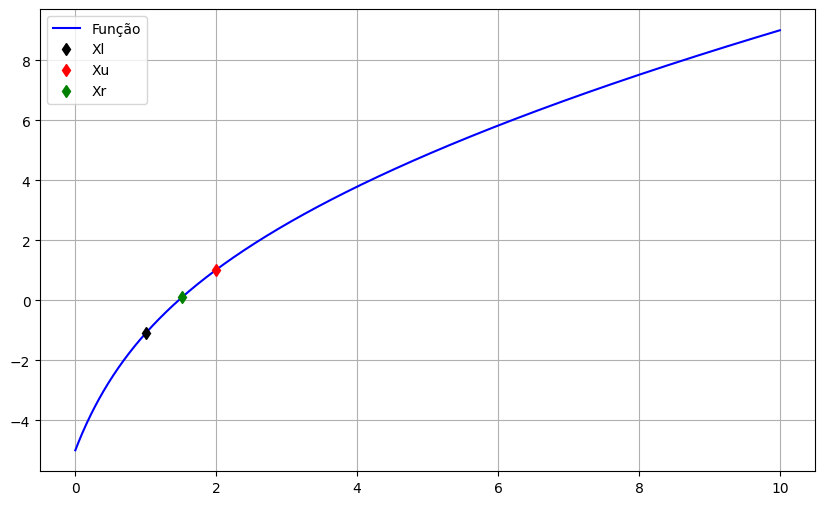

xl = 1
F(xl) = -1.0937205474837897

Xu = 1.5176165605224028
F(xu) = 0.10779579481488533

Xr = 1.4711778342341593
F(xr) = 0.011116018090119084


Erro = 1.4711778342341593 - 1.5176165605224028 / 1.4711778342341593 = 3.1566


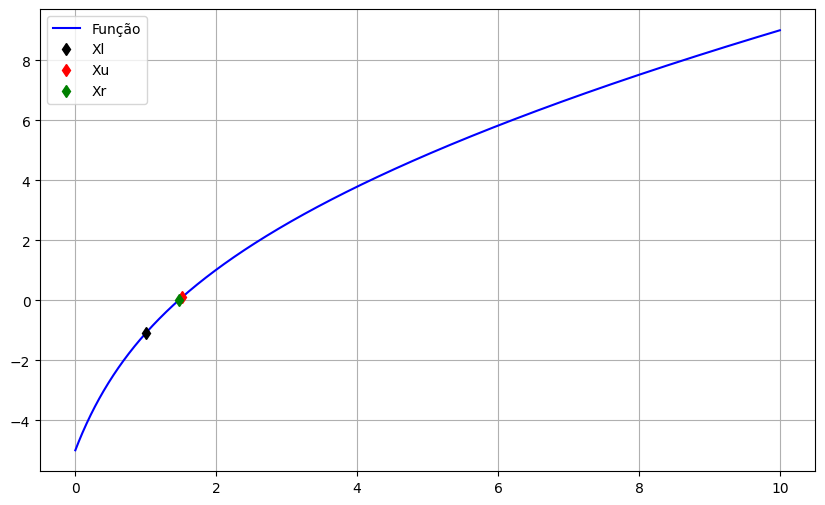

xl = 1
F(xl) = -1.0937205474837897

Xu = 1.4711778342341593
F(xu) = 0.011116018090119084

Xr = 1.4664372042693197
F(xr) = 0.0011427904098342268


Erro = 1.4664372042693197 - 1.4711778342341593 / 1.4664372042693197 = 0.3233


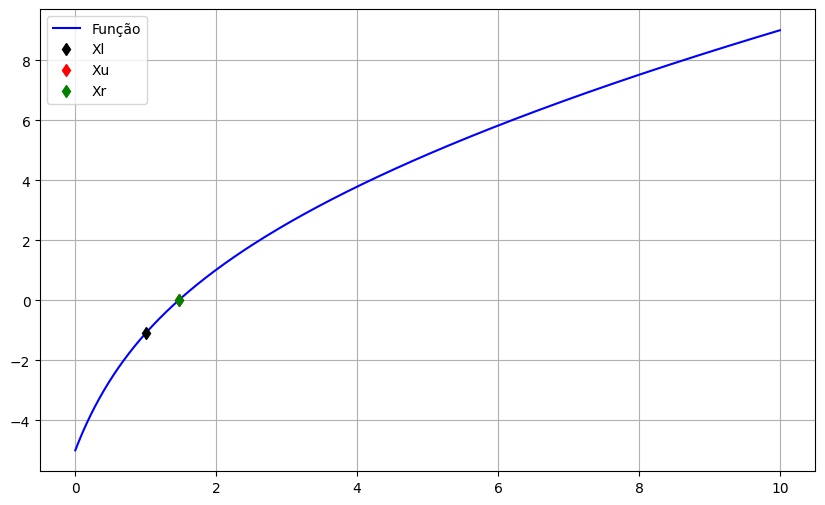

{'Erro': np.float64(0.3233), 'Raiz': np.float64(1.4664372042693197)}

In [35]:
fals_posi(1,2)